# YOLOv8 Fine-tuning Pipeline — UA-DETRAC

Notebook end-to-end, visualize từng bước để **hiểu rõ** quy trình fine-tune YOLOv8 trên dataset UA-DETRAC (Kaggle: `bratjay/ua-detrac-orig`).

**Pipeline:**
1. Setup môi trường & GPU
2. Tải dataset từ Kaggle
3. Khảo sát cấu trúc raw data
4. Parse DETRAC XML annotations
5. Convert sang YOLO format (visualize before/after)
6. Chia train/val/test theo *sequence* (tránh leakage)
7. Phân bố class (mất cân bằng?)
8. Viết `data.yaml`
9. Load pretrained YOLOv8n — xem kiến trúc & params
10. Fine-tune **baseline**
11. Đánh giá baseline (mAP, confusion matrix, sample predictions)
12. Fine-tune **improved** (CBAM + class-weighted BCE)
13. So sánh baseline vs improved
14. Inference demo

> **Chú thích class:** UA-DETRAC gốc có 4 loại xe — `car`, `bus`, `van`, `others`.

> **Về I/O:** dataset khá nặng (~5GB). Convert + train full sẽ mất vài giờ. Có flag `QUICK_MODE` ở cell setup để làm demo nhanh (chỉ dùng ~10 sequences).

## 0. Setup — Imports & GPU check

In [1]:
import os, sys, json, shutil, random, time
from pathlib import Path
from collections import Counter, defaultdict
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cv2
import torch

# ---- root paths ----
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.append(str(PROJECT_ROOT))

RAW_DIR    = PROJECT_ROOT / 'data' / 'raw' / 'ua_detrac'
PROC_DIR   = PROJECT_ROOT / 'data' / 'detrac'         # ảnh+label YOLO format
WEIGHTS    = PROJECT_ROOT / 'weights'
RUNS_DIR   = PROJECT_ROOT / 'runs'
for d in [RAW_DIR, PROC_DIR, WEIGHTS, RUNS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---- config chạy ----
QUICK_MODE = False          # True = subset 10 sequences (demo)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

CLASSES = ['car', 'bus', 'van', 'others']  # 4 class DETRAC
CLS2ID  = {c: i for i, c in enumerate(CLASSES)}

print('Project root:', PROJECT_ROOT)
print('CUDA available :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device         :', torch.cuda.get_device_name(0))
    print('CUDA cap       :', torch.cuda.get_device_capability(0))
print('Torch version  :', torch.__version__)

Project root: /home/xuand/yolov8_finetune
CUDA available : True
Device         : NVIDIA RTX 3500 Ada Generation Laptop GPU
CUDA cap       : (8, 9)
Torch version  : 2.5.1+cu124


In [2]:
# Cài Ultralytics + kagglehub nếu chưa có (idempotent).
try:
    import ultralytics; print('ultralytics', ultralytics.__version__)
except ImportError:
    !pip install -q ultralytics
    import ultralytics; print('ultralytics', ultralytics.__version__)

try:
    import kagglehub; print('kagglehub', kagglehub.__version__)
except ImportError:
    !pip install -q kagglehub
    import kagglehub; print('kagglehub', kagglehub.__version__)

ultralytics 8.4.142
kagglehub 1.0.2


## 1. Tải UA-DETRAC từ Kaggle

**Setup Kaggle credentials** (chỉ cần 1 lần):
1. Lên [kaggle.com](https://www.kaggle.com) → Account → *Create New API Token* → tải `kaggle.json`.
2. Đặt tại `~/.config/kaggle/kaggle.json` (hoặc `~/.kaggle/kaggle.json`), `chmod 600`.

Sau đó `kagglehub` sẽ tự cache dataset vào `~/.cache/kagglehub/`. Cell dưới symlink vào `data/raw/ua_detrac/`.

In [3]:
import kagglehub

# Trả về path tới folder đã extract
cache_path = Path(kagglehub.dataset_download('bratjay/ua-detrac-orig'))
print('Cached at:', cache_path)

# Symlink vào data/raw/ua_detrac để notebook có đường dẫn ổn định
if RAW_DIR.exists() and RAW_DIR.is_symlink():
    RAW_DIR.unlink()
elif RAW_DIR.exists() and not any(RAW_DIR.iterdir()):
    RAW_DIR.rmdir()
if not RAW_DIR.exists():
    RAW_DIR.symlink_to(cache_path)

print('Raw dir:', RAW_DIR, '→', RAW_DIR.resolve())

Cached at: /home/xuand/.cache/kagglehub/datasets/bratjay/ua-detrac-orig/versions/2
Raw dir: /home/xuand/yolov8_finetune/data/raw/ua_detrac → /home/xuand/.cache/kagglehub/datasets/bratjay/ua-detrac-orig/versions/2


## 2. Khảo sát cấu trúc raw dataset

Bản Kaggle `bratjay/ua-detrac-orig` có layout hơi khác chuẩn UA-DETRAC gốc:
```
DETRAC-Images/DETRAC-Images/MVI_XXXXX/imgYYYYY.jpg   # ảnh gộp chung (không tách train/test)
DETRAC-Train-Annotations-XML/DETRAC-Train-Annotations-XML/MVI_XXXXX.xml
DETRAC-Test-Annotations-XML/DETRAC-Test-Annotations-XML/MVI_XXXXX.xml
```
Train/test **phân biệt bằng XML file** (sequence nào có trong `Train-Annotations-XML` là train, tương tự test). Cell dưới auto-detect và in danh sách.

Mỗi sequence là ~600–1500 frame (video xe cộ). XML có định dạng riêng của DETRAC (không phải Pascal VOC).

In [4]:
# Auto-detect layout thật của bản Kaggle.
# Bản `bratjay/ua-detrac-orig` gộp ảnh chung 1 chỗ (DETRAC-Images/DETRAC-Images/MVI_*)
# và chỉ tách train/test qua XML dir → phải phân biệt bằng danh sách XML files.

def find_mvi_root(root: Path) -> Path | None:
    """Tìm thư mục có children match MVI_* (sequence dirs)."""
    for p in root.rglob('*'):
        if not p.is_dir():
            continue
        try:
            if any(c.is_dir() and c.name.startswith('MVI_') for c in p.iterdir()):
                return p
        except (PermissionError, OSError):
            continue
    return None

def find_xml_dir(root: Path, keyword: str) -> Path | None:
    """Tìm thư mục chứa *.xml và tên khớp keyword."""
    for p in root.rglob('*'):
        if p.is_dir() and keyword.lower() in p.name.lower() and any(p.glob('*.xml')):
            return p
    return None

print('Top-level của RAW_DIR:')
for p in sorted(RAW_DIR.iterdir()):
    print(' ', p.name)

img_root       = find_mvi_root(RAW_DIR)
train_ann_root = find_xml_dir(RAW_DIR, 'train-annotations') or find_xml_dir(RAW_DIR, 'train')
test_ann_root  = find_xml_dir(RAW_DIR, 'test-annotations')  or find_xml_dir(RAW_DIR, 'test')

print('\nImage root  :', img_root)
print('Train XML   :', train_ann_root)
print('Test  XML   :', test_ann_root)
assert img_root and train_ann_root and test_ann_root, \
    'Không tìm thấy đủ thư mục — xem cấu trúc bên trên và chỉnh find_* nếu cần'

# Ảnh gộp chung → dùng chung 1 root cho cả train và test
train_img_root = test_img_root = img_root

# Danh sách sequence từ XML (train vs test tách bởi XML dir)
train_seq_set = {p.stem for p in train_ann_root.glob('*.xml')}
test_seq_set  = {p.stem for p in test_ann_root.glob('*.xml')}
all_seqs      = sorted([d.name for d in img_root.iterdir() if d.is_dir() and d.name.startswith('MVI_')])

train_seqs_all = sorted(s for s in all_seqs if s in train_seq_set)
test_seqs_all  = sorted(s for s in all_seqs if s in test_seq_set)

print(f'\n#sequences (tổng có ảnh)      : {len(all_seqs)}')
print(f'#sequences có Train XML       : {len(train_seqs_all)}')
print(f'#sequences có Test  XML       : {len(test_seqs_all)}')

# Alias train_seqs để cell parse XML mẫu ở dưới chạy được
train_seqs = train_seqs_all
sample_seq_dir = img_root / train_seqs[0]
frames = sorted(sample_seq_dir.glob('*.jpg'))
print(f'\nExample: {train_seqs[0]} → {len(frames)} frames')

Top-level của RAW_DIR:
  DETRAC-Images
  DETRAC-MOT-toolkit
  DETRAC-Test-Annotations-XML
  DETRAC-Train-Annotations-XML

Image root  : /home/xuand/yolov8_finetune/data/raw/ua_detrac/DETRAC-Images/DETRAC-Images
Train XML   : /home/xuand/yolov8_finetune/data/raw/ua_detrac/DETRAC-Train-Annotations-XML/DETRAC-Train-Annotations-XML
Test  XML   : /home/xuand/yolov8_finetune/data/raw/ua_detrac/DETRAC-Test-Annotations-XML/DETRAC-Test-Annotations-XML

#sequences (tổng có ảnh)      : 100
#sequences có Train XML       : 60
#sequences có Test  XML       : 40

Example: MVI_20011 → 664 frames


In [5]:
# Xem 1 XML mẫu — hiểu format
assert 'train_seqs' in globals() and train_seqs, \
    "train_seqs chưa được set — hãy chạy lại cell auto-detect ở trên trước (§2)."

sample_xml = train_ann_root / f'{train_seqs[0]}.xml'
if not sample_xml.exists():
    # fallback: lấy XML đầu tiên trong thư mục
    xmls = sorted(train_ann_root.glob('*.xml'))
    assert xmls, f'Không có XML nào trong {train_ann_root}'
    sample_xml = xmls[0]

print('Sample XML :', sample_xml)
print('Size       :', sample_xml.stat().st_size, 'bytes')
print()
print(sample_xml.read_text()[:1500])

Sample XML : /home/xuand/yolov8_finetune/data/raw/ua_detrac/DETRAC-Train-Annotations-XML/DETRAC-Train-Annotations-XML/MVI_20011.xml
Size       : 2240082 bytes

<?xml version="1.0" encoding="utf-8"?>
<sequence name="MVI_20011">
   <sequence_attribute camera_state="unstable" sence_weather="sunny"/>
   <ignored_region>
      <box left="778.75" top="24.75" width="181.75" height="63.5"/>
      <box left="930.75" top="94.75" width="29.75" height="33.5"/>
      <box left="523.75" top="13.75" width="178.5" height="37.5"/>
      <box left="207.75" top="34.75" width="270.5" height="94.5"/>
      <box left="182.75" top="131.75" width="145.5" height="117.5"/>
      <box left="0.5" top="231.75" width="88.75" height="121.5"/>
      <box left="123.75" top="151.75" width="57.5" height="97.5"/>
   </ignored_region>
   <frame density="7" num="1">
      <target_list>
         <target id="1">
            <box left="592.75" top="378.8" width="160.05" height="162.2"/>
            <attribute orientation="18.

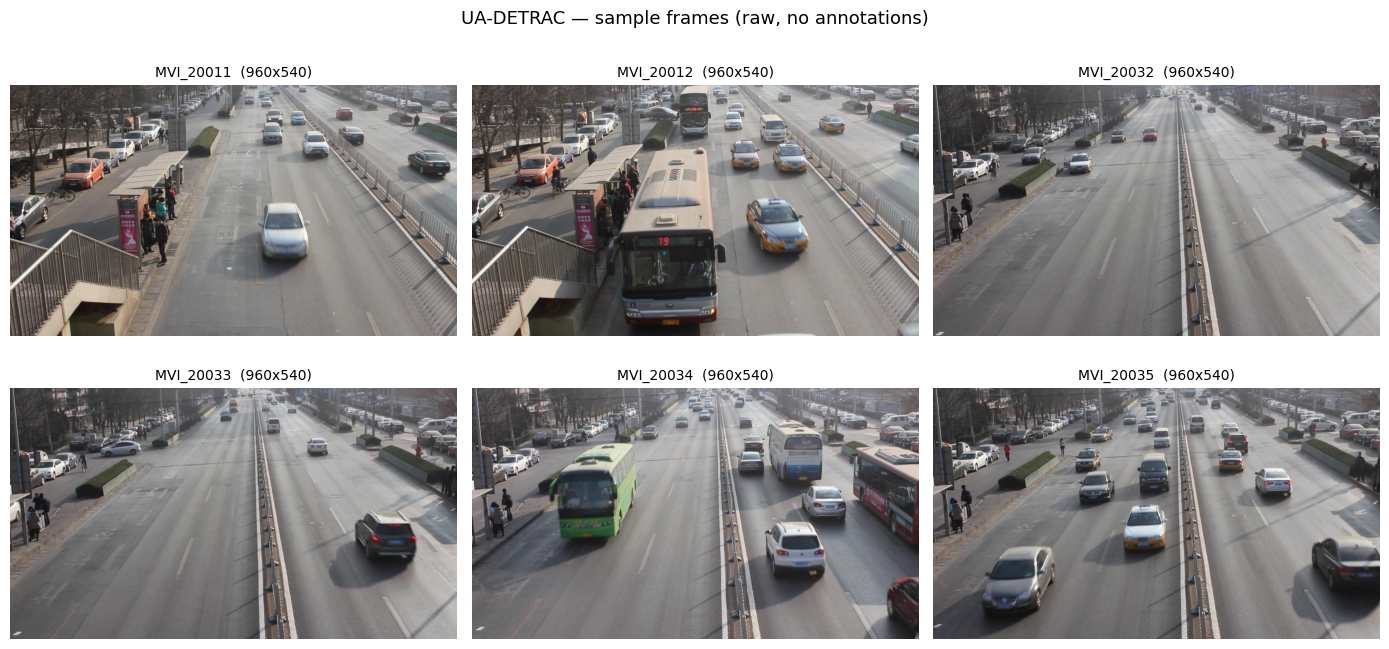

In [6]:
# Visualize 6 frame raw từ 6 sequence khác nhau (chưa có box)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, seq in zip(axes.flat, train_seqs[:6]):
    frames = sorted((train_img_root / seq).glob('*.jpg'))
    img = cv2.cvtColor(cv2.imread(str(frames[len(frames)//2])), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f'{seq}  ({img.shape[1]}x{img.shape[0]})', fontsize=10)
    ax.axis('off')
plt.suptitle('UA-DETRAC — sample frames (raw, no annotations)', fontsize=13)
plt.tight_layout(); plt.show()

## 3. Parse DETRAC XML annotations

DETRAC-XML: mỗi sequence 1 file, chứa nhiều `<frame num="N">` → `<target_list>` → `<target>` với `<box left top width height/>` và `<attribute vehicle_type="car|bus|van|others"/>`.

Ta parse thành DataFrame để dễ khám phá + tính stats.

In [7]:
def parse_detrac_xml(xml_path: Path) -> pd.DataFrame:
    """Parse 1 DETRAC XML → DataFrame [frame, target_id, cls, x, y, w, h].
    Box theo pixel, hệ toạ độ top-left. cls là tên (chưa map ID).
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()
    rows = []
    for frame in root.iter('frame'):
        n = int(frame.get('num'))
        for tgt in frame.iter('target'):
            box = tgt.find('box')
            attr = tgt.find('attribute')
            if box is None or attr is None:
                continue
            rows.append({
                'frame': n,
                'target_id': int(tgt.get('id')),
                'cls': attr.get('vehicle_type', 'others').lower(),
                'x': float(box.get('left')),
                'y': float(box.get('top')),
                'w': float(box.get('width')),
                'h': float(box.get('height')),
            })
    return pd.DataFrame(rows)

df_sample = parse_detrac_xml(sample_xml)
print('Số box parse được:', len(df_sample))
print('Class:', df_sample['cls'].value_counts().to_dict())
df_sample.head()

Số box parse được: 7655
Class: {'car': 7053, 'van': 296, 'others': 211, 'bus': 95}


,frame,target_id,cls,x,y,w,h
0,1,1,car,592.75,378.800,160.05,162.200
1,1,2,car,557.65,120.980,47.20,43.060
2,1,3,car,545.20,88.270,35.25,30.080
3,1,4,car,508.35,67.500,28.00,25.925
4,1,5,car,553.00,70.095,29.55,19.695


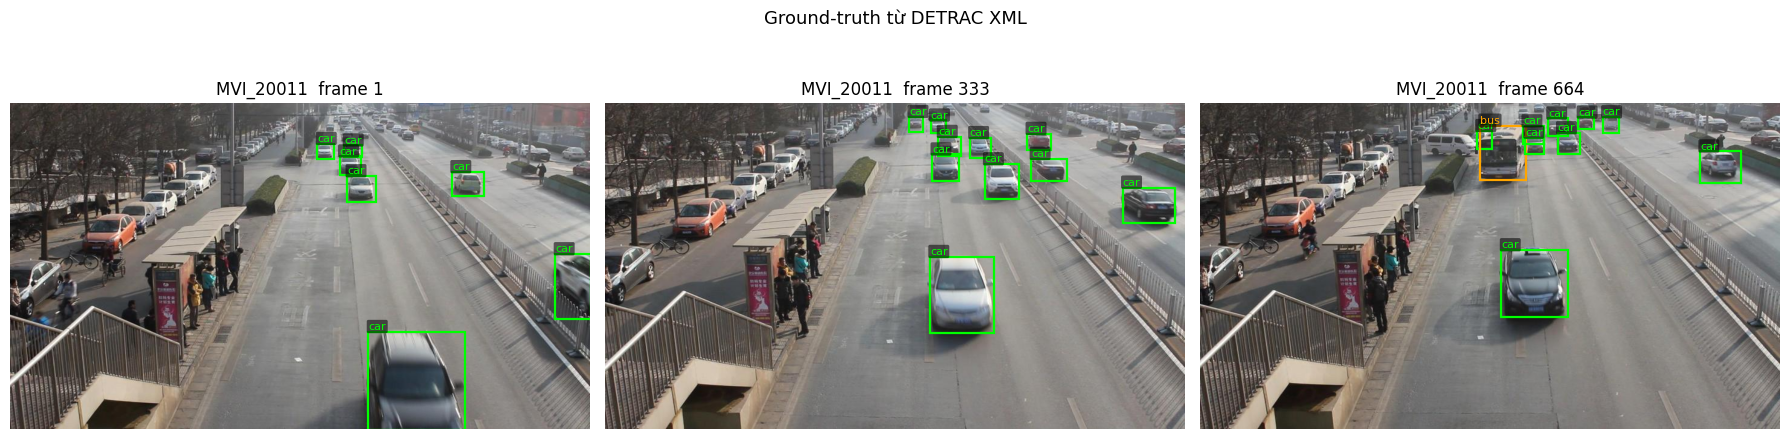

In [8]:
# Vẽ 1 frame + GT box (để đối chiếu parse chính xác)
COLORS = {'car': 'lime', 'bus': 'orange', 'van': 'cyan', 'others': 'magenta'}

def draw_boxes(ax, img, boxes_df, colors=COLORS):
    ax.imshow(img)
    for _, r in boxes_df.iterrows():
        c = colors.get(r['cls'], 'red')
        ax.add_patch(Rectangle((r['x'], r['y']), r['w'], r['h'],
                                fill=False, edgecolor=c, lw=1.6))
        ax.text(r['x'], max(r['y']-4, 0), r['cls'], color=c, fontsize=8,
                bbox=dict(boxstyle='round,pad=0.15', fc='black', ec='none', alpha=0.55))
    ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
frames_in_seq = sorted((train_img_root / train_seqs[0]).glob('*.jpg'))
for ax, i in zip(axes, [0, len(frames_in_seq)//2, len(frames_in_seq)-1]):
    fp = frames_in_seq[i]
    fnum = int(''.join(filter(str.isdigit, fp.stem)))
    img = cv2.cvtColor(cv2.imread(str(fp)), cv2.COLOR_BGR2RGB)
    draw_boxes(ax, img, df_sample[df_sample['frame']==fnum])
    ax.set_title(f'{train_seqs[0]}  frame {fnum}')
plt.suptitle('Ground-truth từ DETRAC XML', fontsize=13); plt.tight_layout(); plt.show()

## 4. Convert sang YOLO format

YOLO cần mỗi ảnh 1 file `.txt` cùng tên với ảnh, mỗi dòng: `class_id x_center y_center width height` (**normalized 0-1**).

Ta cũng flatten: ảnh + label vào cùng 1 thư mục (không giữ cấu trúc sequence), tên file = `{seq}_{frame}.jpg` để tránh trùng.

In [9]:
def to_yolo_line(cls_name: str, x, y, w, h, img_w, img_h) -> str | None:
    if cls_name not in CLS2ID:
        return None
    xc = (x + w/2) / img_w
    yc = (y + h/2) / img_h
    ww = w / img_w
    hh = h / img_h
    # clamp để tránh box vượt biên do rounding
    xc, yc = np.clip([xc, yc], 0, 1)
    ww, hh = np.clip([ww, hh], 0, 1)
    if ww <= 0 or hh <= 0:
        return None
    return f'{CLS2ID[cls_name]} {xc:.6f} {yc:.6f} {ww:.6f} {hh:.6f}'


def convert_sequence(seq_img_dir: Path, xml_path: Path,
                     out_img_dir: Path, out_lbl_dir: Path,
                     seq_name: str) -> tuple[int, int]:
    """Convert 1 sequence. Return (n_frames_written, n_boxes_written)."""
    df = parse_detrac_xml(xml_path)
    by_frame = dict(list(df.groupby('frame')))
    frames = sorted(seq_img_dir.glob('*.jpg'))
    n_f = n_b = 0
    for fp in frames:
        fnum = int(''.join(filter(str.isdigit, fp.stem)))
        boxes = by_frame.get(fnum)
        if boxes is None or boxes.empty:
            continue  # bỏ frame không có annotation
        img = cv2.imread(str(fp))
        if img is None:
            continue
        H, W = img.shape[:2]
        lines = []
        for _, r in boxes.iterrows():
            line = to_yolo_line(r['cls'], r['x'], r['y'], r['w'], r['h'], W, H)
            if line: lines.append(line)
        if not lines:
            continue
        # copy ảnh (symlink cho nhanh) + write label
        new_name = f'{seq_name}_{fp.stem}'
        img_out = out_img_dir / f'{new_name}.jpg'
        if not img_out.exists():
            try:    img_out.symlink_to(fp.resolve())
            except FileExistsError: pass
        (out_lbl_dir / f'{new_name}.txt').write_text('\n'.join(lines))
        n_f += 1; n_b += len(lines)
    return n_f, n_b

# Sanity check: convert 1 sequence trước, verify visually
tmp_img = PROC_DIR / '_check' / 'images'; tmp_lbl = PROC_DIR / '_check' / 'labels'
tmp_img.mkdir(parents=True, exist_ok=True); tmp_lbl.mkdir(parents=True, exist_ok=True)
nf, nb = convert_sequence(train_img_root/train_seqs[0], train_ann_root/f'{train_seqs[0]}.xml',
                          tmp_img, tmp_lbl, train_seqs[0])
print(f'Converted 1 sequence: {nf} frames / {nb} boxes')
print('Sample label file:')
print(next(tmp_lbl.iterdir()).read_text()[:400])

Converted 1 sequence: 664 frames / 7655 boxes
Sample label file:
0 0.492979 0.130250 0.040521 0.050889
0 0.659844 0.047080 0.023750 0.040311
0 0.636849 0.049484 0.024323 0.037428
0 0.710677 0.059580 0.026979 0.046081
0 0.630625 0.314389 0.060521 0.119148
0 0.688229 0.082656 0.026458 0.046078
0 0.740677 0.109099 0.037292 0.047043
0 0.537880 0.224491 0.053510 0.095130
1 0.548302 0.095840 0.051708 0.113061
0 0.571406 0.095156 0.023229 0.049928
0 0.763672 0.202370 


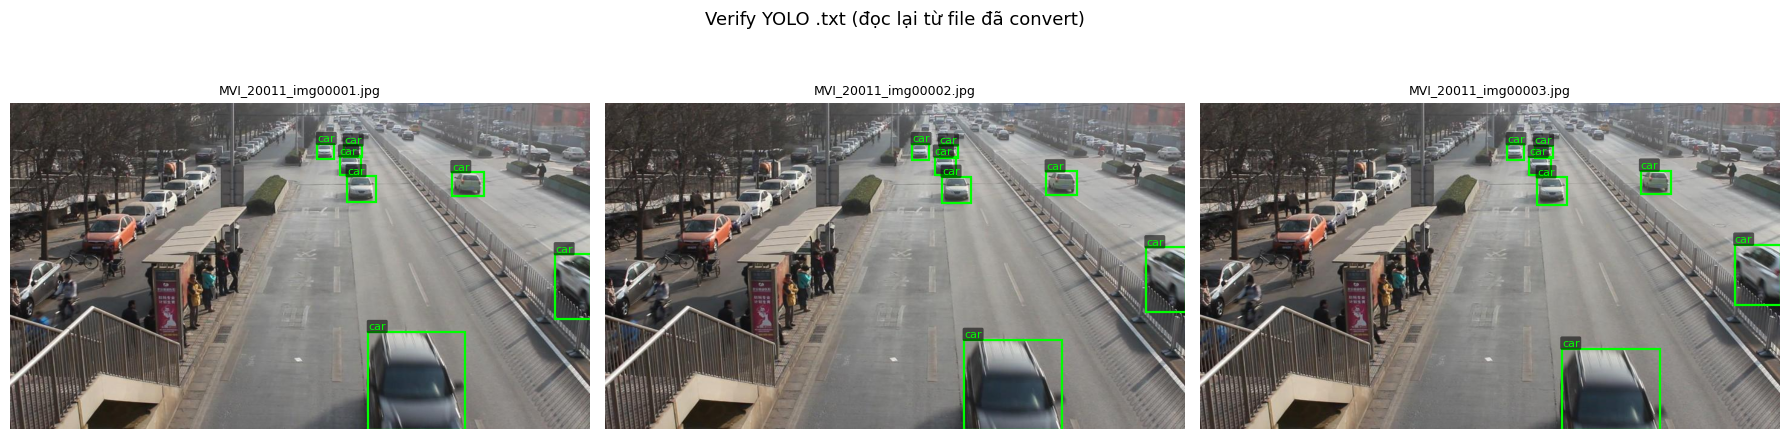

In [10]:
# Visualize: đọc lại từ file YOLO .txt và vẽ → verify convert đúng
def draw_yolo(ax, img_path: Path, lbl_path: Path):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    ax.imshow(img)
    for line in lbl_path.read_text().splitlines():
        cid, xc, yc, ww, hh = line.split()
        cid = int(cid); xc, yc, ww, hh = map(float, (xc, yc, ww, hh))
        x = (xc - ww/2) * W; y = (yc - hh/2) * H
        c = COLORS[CLASSES[cid]]
        ax.add_patch(Rectangle((x, y), ww*W, hh*H, fill=False, edgecolor=c, lw=1.6))
        ax.text(x, max(y-4,0), CLASSES[cid], color=c, fontsize=8,
                bbox=dict(boxstyle='round,pad=0.15', fc='black', ec='none', alpha=0.55))
    ax.axis('off')

sample_imgs = sorted(tmp_img.glob('*.jpg'))[:3]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, ip in zip(axes, sample_imgs):
    draw_yolo(ax, ip, tmp_lbl / f'{ip.stem}.txt')
    ax.set_title(ip.name, fontsize=9)
plt.suptitle('Verify YOLO .txt (đọc lại từ file đã convert)', fontsize=13)
plt.tight_layout(); plt.show()

# clean up sanity check
shutil.rmtree(PROC_DIR / '_check')

## 5. Chia train/val/test theo sequence & convert tất cả

**Điểm quan trọng:** phải split theo *sequence* (video) chứ không theo *frame*, vì các frame liên tiếp trong 1 video gần như giống nhau — nếu random-split thì val/test bị leakage nặng, mAP ảo cao.

- Train sequences từ `DETRAC-Train` → chia ra `train` (80%) và `val` (20%)
- Test sequences từ `DETRAC-Test` → `test`

In [11]:
# Chuẩn bị thư mục output
for split in ['train', 'val', 'test']:
    (PROC_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (PROC_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

# train_seqs_all / test_seqs_all đã tính ở cell auto-detect
if QUICK_MODE:
    train_pool = train_seqs_all[:8]
    test_pool  = test_seqs_all[:2]
else:
    train_pool = train_seqs_all
    test_pool  = test_seqs_all

# Split train → train/val theo sequence (không theo frame — tránh leakage)
rng = random.Random(SEED)
shuf = train_pool[:]
rng.shuffle(shuf)
n_val = max(1, int(0.2 * len(shuf)))
val_seqs   = sorted(shuf[:n_val])
train_seqs = sorted(shuf[n_val:])
test_seqs  = test_pool

print(f'Split by sequence:  train={len(train_seqs)}  val={len(val_seqs)}  test={len(test_seqs)}')
print('Val seqs:', val_seqs[:10], '...' if len(val_seqs)>10 else '')

Split by sequence:  train=48  val=12  test=40
Val seqs: ['MVI_20062', 'MVI_20064', 'MVI_39801', 'MVI_39851', 'MVI_39861', 'MVI_40141', 'MVI_40204', 'MVI_40213', 'MVI_40243', 'MVI_63552'] ...


In [12]:
# Convert tất cả (mất vài phút cho full dataset)
from tqdm.auto import tqdm

def convert_split(seq_list, img_root, ann_root, split):
    tot_f = tot_b = 0
    for s in tqdm(seq_list, desc=f'{split:5}'):
        xml = ann_root / f'{s}.xml'
        seq_dir = img_root / s
        if not xml.exists() or not seq_dir.exists():
            continue
        nf, nb = convert_sequence(seq_dir, xml,
                                   PROC_DIR/'images'/split,
                                   PROC_DIR/'labels'/split, s)
        tot_f += nf; tot_b += nb
    return tot_f, tot_b

stats = {}
stats['train'] = convert_split(train_seqs, train_img_root, train_ann_root, 'train')
stats['val']   = convert_split(val_seqs,   train_img_root, train_ann_root, 'val')
stats['test']  = convert_split(test_seqs,  test_img_root,  test_ann_root,  'test')

print()
for k, (f, b) in stats.items():
    print(f'  {k:5}: {f:6d} frames  |  {b:7d} boxes')

train:   0%|          | 0/48 [00:00<?, ?it/s]

val  :   0%|          | 0/12 [00:00<?, ?it/s]

test :   0%|          | 0/40 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 6. Phân bố class — kiểm tra imbalance

DETRAC nghiêng nặng về `car`. Sẽ ảnh hưởng tới recall của `bus/van/others` → lý do có class-weighted loss ở phần improved.

           car     bus    van  others  %car
train   416202   31232  45301    3059  83.9
val      87651    2419  11750     667  85.5
test    548555   71785  38519   16915  81.2
total  1052408  105436  95570   20641  82.6


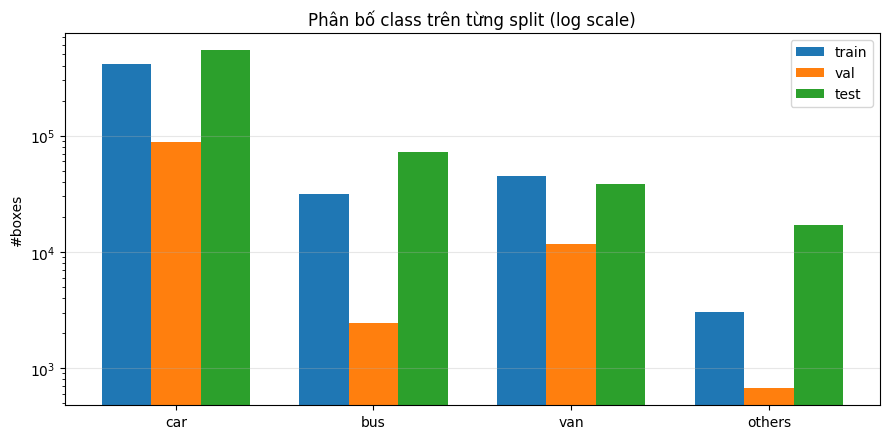

In [ ]:
def count_classes(split):
    c = Counter()
    for lp in (PROC_DIR / 'labels' / split).glob('*.txt'):
        for line in lp.read_text().splitlines():
            c[int(line.split()[0])] += 1
    return c

dist = {s: count_classes(s) for s in ['train','val','test']}
dist_df = pd.DataFrame([[dist[s].get(i,0) for i in range(len(CLASSES))] for s in ['train','val','test']],
                        index=['train','val','test'], columns=CLASSES)
dist_df.loc['total'] = dist_df.sum(axis=0)
dist_df['%car'] = (dist_df['car'] / dist_df.sum(axis=1) * 100).round(1)
print(dist_df)

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(CLASSES)); w = 0.25
for i, split in enumerate(['train','val','test']):
    ax.bar(x + (i-1)*w, [dist[split].get(j, 0) for j in range(len(CLASSES))], w, label=split)
ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.set_ylabel('#boxes'); ax.set_yscale('log')
ax.set_title('Phân bố class trên từng split (log scale)')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Viết `data.yaml`

Ultralytics đọc file này để biết đường dẫn ảnh + tên class.

In [ ]:
DATA_YAML = PROJECT_ROOT / 'data' / 'detrac.yaml'
yaml_txt = f"""# UA-DETRAC 4-class YOLO dataset (auto-generated by notebook)
path: {PROC_DIR}
train: images/train
val:   images/val
test:  images/test

nc: {len(CLASSES)}
names:
"""
for i, c in enumerate(CLASSES):
    yaml_txt += f'  {i}: {c}\n'
DATA_YAML.write_text(yaml_txt)
print(DATA_YAML.read_text())

# UA-DETRAC 4-class YOLO dataset (auto-generated by notebook)
path: /home/xuand/yolov8_finetune/data/detrac
train: images/train
val:   images/val
test:  images/test

nc: 4
names:
  0: car
  1: bus
  2: van
  3: others



## 8. Load pretrained YOLOv8n — xem kiến trúc

`yolov8n.pt` = nano scale (~3.2M params), pre-trained COCO 80-class. Khi fine-tune 4-class, Ultralytics auto-thay head cuối.

In [ ]:
from ultralytics import YOLO

PRETRAINED = WEIGHTS / 'yolov8n.pt'
if not PRETRAINED.exists():
    # ultralytics auto-download vào cwd, ta di chuyển vào weights/
    m_tmp = YOLO('yolov8n.pt')
    src = Path('yolov8n.pt')
    if src.exists():
        shutil.move(str(src), PRETRAINED)

model = YOLO(str(PRETRAINED))
print('Task     :', model.task)
print('#params  :', sum(p.numel() for p in model.model.parameters())/1e6, 'M')
print('#layers  :', len(list(model.model.modules())))
print('COCO nc  :', model.model.nc)
print('\nHead sẽ được reset về 4 class khi train.')

Task     : detect
#params  : 3.1572 M
#layers  : 225
COCO nc  : 80

Head sẽ được reset về 4 class khi train.


## 9. Fine-tune baseline

**Về siêu tham số:**
- `imgsz=640` — chuẩn YOLOv8
- `batch=32` — VRAM chỉ dùng 20% ở batch 16, tăng lên 32 để giảm overhead. Nếu OOM → hạ 24 hoặc 16.
- `workers=12` — nhiều DataLoader worker để CPU decode ảnh song song (GPU không bị đói data)
- `cache='ram'` — cache toàn bộ dataset decoded vào RAM. Dataset chỉ 1.1GB, RAM còn 39GB → thoải mái. Bỏ qua đọc disk mỗi epoch, GPU util từ ~35% → ~85%.
- `epochs=50` — dataset lớn (~68K frames) nên 50 epoch đã tốt, có `patience=15` early-stop.
- `lr0` mặc định `0.01` (SGD với momentum). Ultralytics tự cosine schedule.

> **Với RTX 3500 Ada + cache RAM**: ~40-60 phút cho full 50 epoch (thay vì 2-4 giờ khi không cache).

In [ ]:
EPOCHS   = 50 if not QUICK_MODE else 5
BATCH    = 32          # tăng từ 16 → 32 (VRAM chỉ dùng 20% với batch 16)
IMGSZ    = 640
WORKERS  = 12          # tăng từ mặc định 8 để CPU decode nhiều hơn

baseline = YOLO(str(PRETRAINED))
results_baseline = baseline.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    workers=WORKERS,
    cache='ram',       # cache decoded images vào RAM (1.1GB dataset, 39GB RAM sẵn có)
    device=0,
    project=str(RUNS_DIR / 'yolo_baseline'),
    name='exp',
    patience=15,
    seed=SEED,
    exist_ok=True,
)
print('Weights best:', results_baseline.save_dir / 'weights' / 'best.pt')

New https://pypi.org/project/ultralytics/8.4.146 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.142 🚀 Python-3.10.20 torch-2.5.1+cu124 CUDA:0 (NVIDIA RTX 3500 Ada Generation Laptop GPU, 12282MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/xuand/yolov8_finetune/data/detrac.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, ma

KeyboardInterrupt: 

In [ ]:
# Visualize loss + mAP curve từ results.csv
def plot_training_curves(run_dir: Path, title: str):
    csv = run_dir / 'results.csv'
    df = pd.read_csv(csv)
    df.columns = [c.strip() for c in df.columns]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    # Loss
    for c, lbl in [('train/box_loss','train box'),('train/cls_loss','train cls'),
                   ('val/box_loss','val box'),('val/cls_loss','val cls')]:
        if c in df: axes[0].plot(df['epoch'], df[c], label=lbl)
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
    axes[0].set_title(f'{title} — losses'); axes[0].legend(); axes[0].grid(alpha=0.3)
    # mAP
    for c, lbl in [('metrics/mAP50(B)','mAP@0.5'),('metrics/mAP50-95(B)','mAP@0.5:0.95'),
                   ('metrics/precision(B)','precision'),('metrics/recall(B)','recall')]:
        if c in df: axes[1].plot(df['epoch'], df[c], label=lbl)
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('metric')
    axes[1].set_title(f'{title} — val metrics'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return df

base_run_dir = Path(results_baseline.save_dir)
df_base = plot_training_curves(base_run_dir, 'YOLOv8n baseline')

## 10. Đánh giá baseline trên test set

In [ ]:
BASE_BEST = base_run_dir / 'weights' / 'best.pt'
m_baseline = YOLO(str(BASE_BEST))
eval_base = m_baseline.val(data=str(DATA_YAML), split='test',
                            project=str(RUNS_DIR/'yolo_baseline'), name='test_eval',
                            plots=True, exist_ok=True)
print('mAP@0.5    :', float(eval_base.box.map50))
print('mAP@0.5:.95:', float(eval_base.box.map))
print('\nPer-class:')
for i, c in enumerate(CLASSES):
    if i < len(eval_base.box.ap50):
        print(f'  {c:8s}  AP50={float(eval_base.box.ap50[i]):.3f}  '
              f'P={float(eval_base.box.p[i]):.3f}  R={float(eval_base.box.r[i]):.3f}')

In [ ]:
# Xem confusion matrix Ultralytics tự vẽ
from IPython.display import Image, display
cm_path = Path(eval_base.save_dir) / 'confusion_matrix.png'
if cm_path.exists():
    display(Image(str(cm_path)))

In [ ]:
# Sample predictions vs GT — side by side
test_imgs = sorted((PROC_DIR/'images'/'test').glob('*.jpg'))
sample = random.Random(0).sample(test_imgs, 3)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for row, ip in enumerate(sample):
    # GT (left)
    draw_yolo(axes[row,0], ip, PROC_DIR/'labels'/'test'/f'{ip.stem}.txt')
    axes[row,0].set_title(f'GT — {ip.name}', fontsize=10)
    # Prediction (right)
    res = m_baseline.predict(str(ip), conf=0.25, verbose=False)[0]
    img = cv2.cvtColor(cv2.imread(str(ip)), cv2.COLOR_BGR2RGB)
    axes[row,1].imshow(img)
    for b, c, s in zip(res.boxes.xyxy.cpu().numpy(),
                        res.boxes.cls.cpu().numpy().astype(int),
                        res.boxes.conf.cpu().numpy()):
        col = COLORS[CLASSES[c]]
        axes[row,1].add_patch(Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                         fill=False, edgecolor=col, lw=1.6))
        axes[row,1].text(b[0], max(b[1]-4,0), f'{CLASSES[c]} {s:.2f}',
                          color=col, fontsize=8,
                          bbox=dict(boxstyle='round,pad=0.15', fc='black', ec='none', alpha=0.55))
    axes[row,1].axis('off'); axes[row,1].set_title(f'Pred — {ip.name}', fontsize=10)
plt.suptitle('Baseline: GT vs Prediction', fontsize=13); plt.tight_layout(); plt.show()

## 11. Fine-tune improved — YOLOv8 + CBAM + class-weighted BCE

**Cải tiến:**
- **CBAM** (Convolutional Block Attention Module) chèn sau 3 output của neck (P3/P4/P5) → recalibrate channel + spatial attention. Thêm ~0.1M params.
- **class_weights** = `N / (K · n_c)` (chuẩn hoá mean=1) — Ultralytics nhân trực tiếp vào BCE cls loss. Kỳ vọng tăng recall của class hiếm.

Dùng lại code trong [scripts/train_yolo_improved.py](../scripts/train_yolo_improved.py) — chỉ patch YAML về 4 class.

In [ ]:
from scripts.train_yolo_improved import register_cbam, compute_class_weights

# Adjust YAML: nc=4 (DETRAC)
CBAM_YAML_SRC = PROJECT_ROOT / 'models' / 'yolov8_improved' / 'yolov8n-cbam.yaml'
CBAM_YAML     = PROJECT_ROOT / 'models' / 'yolov8_improved' / 'yolov8n-cbam-detrac.yaml'
src_text = CBAM_YAML_SRC.read_text()
# Thay nc: 5 → nc: 4 (regex simple)
import re
src_text = re.sub(r'^nc:\s*\d+', f'nc: {len(CLASSES)}', src_text, flags=re.M)
CBAM_YAML.write_text(src_text)

register_cbam()  # đăng ký NeckCBAM vào parse_model

improved = YOLO(str(CBAM_YAML))       # build kiến trúc
improved.load(str(PRETRAINED))        # transfer backbone weights
print('#params improved:', sum(p.numel() for p in improved.model.parameters())/1e6, 'M')

# class weights từ train labels
cw = compute_class_weights(PROC_DIR/'labels'/'train', num_classes=len(CLASSES))
improved.model.class_weights = cw
print('class_weights:', dict(zip(CLASSES, cw.tolist())))

In [ ]:
results_improved = improved.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    workers=WORKERS,
    cache='ram',
    device=0,
    project=str(RUNS_DIR / 'yolo_improved'),
    name='exp',
    patience=15,
    seed=SEED,
    exist_ok=True,
)
imp_run_dir = Path(results_improved.save_dir)
df_imp = plot_training_curves(imp_run_dir, 'YOLOv8n + CBAM (improved)')

In [ ]:
IMP_BEST = imp_run_dir / 'weights' / 'best.pt'
m_improved = YOLO(str(IMP_BEST))
eval_imp = m_improved.val(data=str(DATA_YAML), split='test',
                           project=str(RUNS_DIR/'yolo_improved'), name='test_eval',
                           plots=True, exist_ok=True)
print('mAP@0.5    :', float(eval_imp.box.map50))
print('mAP@0.5:.95:', float(eval_imp.box.map))

## 12. So sánh baseline vs improved

In [ ]:
def per_class(eval_obj):
    return {
        'AP50':      [float(x) for x in eval_obj.box.ap50],
        'precision': [float(x) for x in eval_obj.box.p],
        'recall':    [float(x) for x in eval_obj.box.r],
    }

pc_base = per_class(eval_base)
pc_imp  = per_class(eval_imp)

# Table so sánh
comp = pd.DataFrame({
    'model':        ['baseline', 'improved'],
    'mAP@0.5':      [float(eval_base.box.map50), float(eval_imp.box.map50)],
    'mAP@0.5:.95':  [float(eval_base.box.map),   float(eval_imp.box.map)],
})
for i, c in enumerate(CLASSES):
    comp[f'R_{c}'] = [pc_base['recall'][i] if i<len(pc_base['recall']) else np.nan,
                      pc_imp ['recall'][i] if i<len(pc_imp ['recall']) else np.nan]
print(comp.to_string(index=False))

# Save
out_csv = PROJECT_ROOT / 'results' / 'tables' / 'comparison.csv'
out_csv.parent.mkdir(parents=True, exist_ok=True)
comp.to_csv(out_csv, index=False)
print(f'\n→ {out_csv}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
# mAP bar
x = np.arange(2); w = 0.35
axes[0].bar(x - w/2, [comp['mAP@0.5'][0], comp['mAP@0.5:.95'][0]], w, label='baseline')
axes[0].bar(x + w/2, [comp['mAP@0.5'][1], comp['mAP@0.5:.95'][1]], w, label='improved')
axes[0].set_xticks(x); axes[0].set_xticklabels(['mAP@0.5', 'mAP@0.5:.95'])
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y'); axes[0].set_title('Overall mAP')
for i, (b, i_) in enumerate(zip([comp['mAP@0.5'][0], comp['mAP@0.5:.95'][0]],
                                 [comp['mAP@0.5'][1], comp['mAP@0.5:.95'][1]])):
    axes[0].text(i - w/2, b, f'{b:.3f}', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + w/2, i_,f'{i_:.3f}', ha='center', va='bottom', fontsize=9)

# Per-class recall
x = np.arange(len(CLASSES))
axes[1].bar(x - w/2, pc_base['recall'][:len(CLASSES)], w, label='baseline')
axes[1].bar(x + w/2, pc_imp ['recall'][:len(CLASSES)], w, label='improved')
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASSES)
axes[1].set_ylabel('recall'); axes[1].set_title('Per-class recall')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
fig_path = PROJECT_ROOT / 'results' / 'figures' / 'comparison.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150); plt.show()
print(f'→ {fig_path}')

## 13. Inference demo — baseline vs improved cạnh nhau

In [ ]:
def infer_and_draw(ax, model, img_path, title):
    res = model.predict(str(img_path), conf=0.25, verbose=False)[0]
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.axis('off'); ax.set_title(title, fontsize=10)
    for b, c, s in zip(res.boxes.xyxy.cpu().numpy(),
                        res.boxes.cls.cpu().numpy().astype(int),
                        res.boxes.conf.cpu().numpy()):
        col = COLORS[CLASSES[c]]
        ax.add_patch(Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                fill=False, edgecolor=col, lw=1.5))
        ax.text(b[0], max(b[1]-4,0), f'{CLASSES[c]} {s:.2f}',
                 color=col, fontsize=7,
                 bbox=dict(boxstyle='round,pad=0.1', fc='black', ec='none', alpha=0.55))

sample = random.Random(1).sample(test_imgs, 4)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for row, ip in enumerate(sample):
    infer_and_draw(axes[row,0], m_baseline, ip, f'baseline — {ip.name}')
    infer_and_draw(axes[row,1], m_improved, ip, f'improved — {ip.name}')
plt.suptitle('Inference: baseline vs improved', fontsize=13); plt.tight_layout(); plt.show()

---

## Kết luận

Notebook đã đi qua toàn bộ pipeline fine-tune YOLOv8:

1. **Data**: tải, khảo sát, parse DETRAC XML, convert YOLO format, split theo sequence.
2. **Analysis**: phân bố class để phát hiện imbalance.
3. **Train**: transfer learning từ COCO weights → 4 class DETRAC.
4. **Evaluate**: mAP, per-class metrics, confusion matrix, sample predictions.
5. **Improved**: thêm CBAM ở neck + class-weighted BCE, so sánh với baseline.

**Điểm quan trọng nhất nhớ:**
- **Split theo video**, không theo frame → tránh leakage.
- **Đọc lại file .txt và vẽ** để verify convert đúng.
- **Curve loss/mAP** cho biết đã hội tụ chưa, có overfit không.
- Cải tiến chỉ có ý nghĩa khi *có gain trên val/test*, không phải trên train.